In [1]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


# MobileNetV2 파인튜닝 - 연필 / 핸드폰 분류
**실행 순서대로 셀을 실행하세요.**

런타임 > 런타임 유형 변경 > **GPU** 선택 후 시작하세요.

## 1. 구글 드라이브 연결

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q icrawler

In [4]:
import os
from icrawler.builtin import BingImageCrawler

BASE = '/content/drive/MyDrive/cv_data'

# 수집할 키워드와 저장 경로
CRAWL_CONFIG = {
    'pencil':   'pencil object white background',
    'phone':    'smartphone mobile phone object',
    'notebook': 'notebook paper spiral bound object',
}

NUM_IMAGES = 150  # 클래스당 수집할 이미지 수 (train 80% / val 20% 자동 분할)

for cls, keyword in CRAWL_CONFIG.items():
    save_dir = f'/content/raw/{cls}'
    os.makedirs(save_dir, exist_ok=True)
    print(f'[{cls}] 크롤링 중... ({keyword})')
    crawler = BingImageCrawler(storage={'root_dir': save_dir})
    crawler.crawl(keyword=keyword, max_num=NUM_IMAGES)
    print(f'[{cls}] 완료: {len(os.listdir(save_dir))}장')

[pencil] 크롤링 중... (pencil object white background)


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/022/469/921/large_2x/pencil-isolated-white-background-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/006/091/762/non_2x/pencil-on-white-background-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/051/237/673/non_2x/pencil-with-white-background-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/029/204/230/non_2x/pencil-isolated-on-white-background-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/022/469/920/large_2x/pencil-isolated-white-background-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/022/469/916/non_2x/pencil-isolated-white-background-free-phot

[pencil] 완료: 49장
[phone] 크롤링 중... (smartphone mobile phone object)


ERROR:downloader:Response status code 403, file https://png.pngtree.com/background/20230916/original/pngtree-white-mobile-phone-object-cell-screen-photo-picture-image_5107030.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/011/157/544/original/mobile-phone-cartoon-icon-illustration-technology-object-icon-concept-isolated-premium-flat-cartoon-style-vector.jpg
ERROR:downloader:Response status code 403, file https://wallpapercrafter.com/desktop2/730977-mobile-Phone-smart-Phone-telephone-technology-communication.jpg
ERROR:downloader:Response status code 403, file https://images.creativemarket.com/0.1.0/ps/375688/1160/773/m1/fpnw/wm0/24-playing-with-phone-stopping-glare-copy-.jpg
ERROR:downloader:Response status code 403, file https://cdn.3dmodels.org/wp-content/uploads/cgaxis/3992_cgaxis_electronics_015/cgaxis_electronics_015_1000_0001.jpg
ERROR:downloader:Exception caught when downloading file https://thumbs.dreamstime.com/z/smartp

[phone] 완료: 50장
[notebook] 크롤링 중... (notebook paper spiral bound object)


ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/172402513/photo/spiral-book.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/149402372/photo/notebook.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1492974792/vector/a-lined-notebook-in-a-spiral-binding.jpg
ERROR:downloader:Response status code 404, file https://i.kinja-img.com/image/upload/c_fit,q_60,w_645/bdea172be037d445aeebdc6ddf82f832.jpg


[notebook] 완료: 73장


## 2. 이미지 크롤링으로 데이터 수집

Bing 이미지 검색으로 연필/핸드폰 사진을 자동 수집합니다.

In [5]:
!pip install -q icrawler

In [6]:
import os
from icrawler.builtin import BingImageCrawler

BASE = '/content/drive/MyDrive/cv_data'

# 수집할 키워드와 저장 경로
CRAWL_CONFIG = {
    'pencil': 'pencil object white background',
    'phone':  'smartphone mobile phone object',
}

NUM_IMAGES = 150  # 클래스당 수집할 이미지 수 (train 80% / val 20% 자동 분할)

for cls, keyword in CRAWL_CONFIG.items():
    save_dir = f'/content/raw/{cls}'
    os.makedirs(save_dir, exist_ok=True)
    print(f'[{cls}] 크롤링 중... ({keyword})')
    crawler = BingImageCrawler(storage={'root_dir': save_dir})
    crawler.crawl(keyword=keyword, max_num=NUM_IMAGES)
    print(f'[{cls}] 완료: {len(os.listdir(save_dir))}장')

[pencil] 크롤링 중... (pencil object white background)


ERROR:downloader:Response status code 403, file https://png.pngtree.com/thumb_back/fw800/background/20220104/pngtree-color-pencils-on-a-white-background-object-sketch-kid-photo-image_27348882.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/010/295/319/non_2x/pencils-on-pure-white-background-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/010/298/903/non_2x/pencils-on-pure-white-background-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/011/603/488/non_2x/isolated-pencils-on-white-background-free-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/018/789/502/large_2x/amazing-isolated-pencils-on-pure-white-background-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/027/574/571/origin

[pencil] 완료: 67장
[phone] 크롤링 중... (smartphone mobile phone object)


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/010/983/023/original/black-outline-smartphone-icon-handphone-clipart-vector.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/020/146/452/non_2x/smartphone-moblie-phone-set-with-white-screen-and-black-body-old-and-new-smartphone-and-button-phone-eps-10-vector.jpg
ERROR:downloader:Response status code 403, file https://get.pxhere.com/photo/smartphone-mobile-technology-phone-gadget-mobile-phone-device-smart-phone-case-rectangle-cellphone-smart-cell-phones-electronic-device-portable-communications-device-1292725.jpg
ERROR:downloader:Response status code 403, file https://c.pxhere.com/photos/5a/d8/mobile_i_phone_iphone_5_3d_mobile_mobile_photography-1223117.jpg
ERROR:downloader:Response status code 403, file https://c.pxhere.com/images/c7/02/b0f8b0ec4a853f4e24100aff3878-1595196.jpg
ERROR:downloader:Response status code 403, file https

[phone] 완료: 64장


## 3. train / val 자동 분할

In [7]:
import shutil
import random
from pathlib import Path

VAL_RATIO = 0.2
random.seed(42)

for cls in CRAWL_CONFIG:
    files = list(Path(f'/content/raw/{cls}').glob('*'))
    files = [f for f in files if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    random.shuffle(files)

    n_val = int(len(files) * VAL_RATIO)
    splits = {'val': files[:n_val], 'train': files[n_val:]}

    for split, split_files in splits.items():
        dst = Path(f'{BASE}/{split}/{cls}')
        dst.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            shutil.copy(f, dst / f.name)
        print(f'{split}/{cls}: {len(split_files)}장')

val/pencil: 13장
train/pencil: 54장
val/phone: 12장
train/phone: 52장


## 4. 데이터 확인

In [8]:
for split in ['train', 'val']:
    for cls in CRAWL_CONFIG:
        path = f'{BASE}/{split}/{cls}'
        files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f'{split}/{cls}: {len(files)}장')

train/pencil: 54장
train/phone: 52장
val/pencil: 13장
val/phone: 12장


## 5. 라이브러리 임포트

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import matplotlib.pyplot as plt
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


## 6. 데이터 전처리 및 로더

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(f'{BASE}/train', transform=train_transform)
val_dataset   = datasets.ImageFolder(f'{BASE}/val',   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print(f'클래스: {CLASS_NAMES}')  # ['pencil', 'phone']
print(f'학습: {len(train_dataset)}장 / 검증: {len(val_dataset)}장')

클래스: ['pencil', 'phone']
학습: 106장 / 검증: 25장


## 7. 샘플 이미지 확인

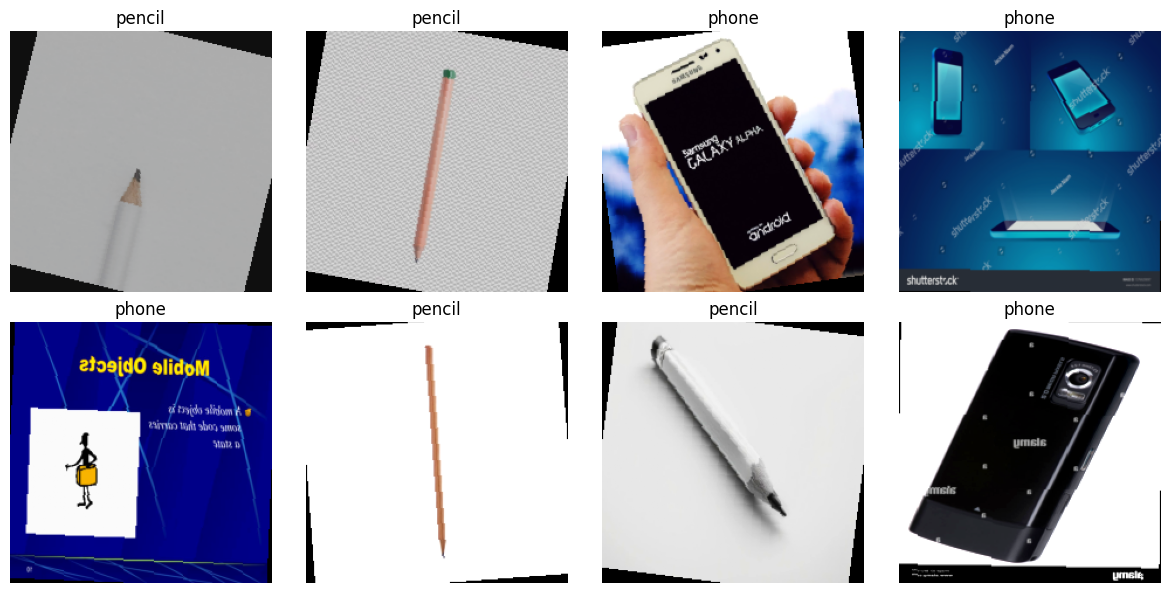

In [11]:
imgs, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img = imgs[i] * std[:, None, None] + mean[:, None, None]
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(CLASS_NAMES[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. 모델 정의 (MobileNetV2 파인튜닝)

In [12]:
model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

# 특징 추출 레이어 고정
for param in model.features.parameters():
    param.requires_grad = False

# 분류 레이어를 2클래스로 교체
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.last_channel, len(CLASS_NAMES)),
)

model = model.to(device)
print('모델 준비 완료')
print(f'학습 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s]


모델 준비 완료
학습 파라미터 수: 2,562


## 9. 학습

In [13]:
EPOCHS    = 20
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

best_acc   = 0.0
best_model = None
history    = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        loader = train_loader if phase == 'train' else val_loader

        total_loss, correct = 0.0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(imgs)
                loss    = criterion(outputs, labels)
                preds   = outputs.argmax(dim=1)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (preds == labels).sum().item()

        epoch_loss = total_loss / len(loader.dataset)
        epoch_acc  = correct   / len(loader.dataset)
        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)

        if phase == 'val' and epoch_acc > best_acc:
            best_acc   = epoch_acc
            best_model = copy.deepcopy(model.state_dict())

    scheduler.step()
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'train loss {history["train_loss"][-1]:.4f} acc {history["train_acc"][-1]:.4f} | '
          f'val loss {history["val_loss"][-1]:.4f} acc {history["val_acc"][-1]:.4f}')

print(f'\n최고 검증 정확도: {best_acc:.4f}')

Epoch  1/20 | train loss 0.7547 acc 0.5755 | val loss 0.8460 acc 0.4800
Epoch  2/20 | train loss 0.5934 acc 0.6604 | val loss 0.4188 acc 0.8800
Epoch  3/20 | train loss 0.4490 acc 0.8019 | val loss 0.3009 acc 1.0000
Epoch  4/20 | train loss 0.2993 acc 0.9434 | val loss 0.2501 acc 1.0000
Epoch  5/20 | train loss 0.2583 acc 0.9434 | val loss 0.2019 acc 1.0000
Epoch  6/20 | train loss 0.2344 acc 0.9245 | val loss 0.1627 acc 1.0000
Epoch  7/20 | train loss 0.1670 acc 0.9528 | val loss 0.1436 acc 1.0000
Epoch  8/20 | train loss 0.1796 acc 0.9528 | val loss 0.1467 acc 1.0000
Epoch  9/20 | train loss 0.1707 acc 0.9434 | val loss 0.1456 acc 1.0000
Epoch 10/20 | train loss 0.1890 acc 0.9528 | val loss 0.1385 acc 1.0000
Epoch 11/20 | train loss 0.1750 acc 0.9528 | val loss 0.1391 acc 1.0000
Epoch 12/20 | train loss 0.1675 acc 0.9528 | val loss 0.1372 acc 1.0000
Epoch 13/20 | train loss 0.1613 acc 0.9528 | val loss 0.1322 acc 1.0000
Epoch 14/20 | train loss 0.1596 acc 0.9623 | val loss 0.1328 acc

## 10. 학습 곡선 확인

In [14]:
model.load_state_dict(best_model)

save_data = {
    'model_state_dict': best_model,
    'class_names':      CLASS_NAMES,
    'best_val_acc':     best_acc,
}

# 구글 드라이브 저장
drive_path = '/content/drive/MyDrive/CV/2_fine-tuning/model.pt'
os.makedirs(os.path.dirname(drive_path), exist_ok=True)
torch.save(save_data, drive_path)
print(f'드라이브 저장 완료: {drive_path}')

# 로컬 PC 다운로드
local_path = '/content/model.pt'
torch.save(save_data, local_path)
from google.colab import files
files.download(local_path)
print('로컬 다운로드 시작됨')

print(f'클래스: {CLASS_NAMES}')
print(f'검증 정확도: {best_acc:.2%}')

드라이브 저장 완료: /content/drive/MyDrive/CV/model.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

로컬 다운로드 시작됨
클래스: ['pencil', 'phone']
검증 정확도: 100.00%
